# Lab 5 - Exploratory Data Analysis

In [2]:
%matplotlib inline

## General Instructions

In this course, Labs are the chance to applying concepts and methods discussed in the module.
They are a low stakes (pass/fail) opportunity for you to try your hand at *doing*.
Please make sure you follow the general Lab instructions, described in the Syllabus.
The summary is:

* Discussions should start as students work through the material, first Wednesday at the start of the new Module week. 
* Labs are due by Sunday. 
* Lab solutions are released Monday.  
* Post Self Evaluation and Lab to Lab Group on Blackboard and Lab to Module on Blackboard on Monday.

The last part is important because the Problem Sets will require you to perform the same or similar tasks without guidance.
Problem Sets are your opportunity to demonstrate that you understand how to apply the concepts and methods discussed in the relevant Modules and Labs.

## Specific Instructions

1.  For Blackboard submissions, if there are no accompanying files, you should submit *only* your notebook and it should be named using *only* your JHED id: fsmith79.ipynb for example if your JHED id were "fsmith79". If the assignment requires additional files, you should name the *folder/directory* your JHED id and put all items in that folder/directory, ZIP it up (only ZIP...no other compression), and submit it to Blackboard.

    * do **not** use absolute paths in your notebooks. All resources should located in the same directory as the rest of your assignments.
    * the directory **must** be named your JHED id and **only** your JHED id.
    * do **not** return files provided by us (data files, .py files)


2. Data Science is as much about what you write (communicating) as the code you execute (researching). In many places, you will be required to execute code and discuss both the purpose and the result. Additionally, Data Science is about reproducibility and transparency. This includes good communication with your team and possibly with yourself. Therefore, you must show **all** work.

3. Avail yourself of the Markdown/Codecell nature of the notebook. If you don't know about Markdown, look it up. Your notebooks should not look like ransom notes. Don't make everything bold. Clearly indicate what question you are answering.

4. Submit a cleanly executed notebook. The first code cell should say `In [1]` and each successive code cell should increase by 1 throughout the notebook.

## Exploratory Data Analysis

In this Module, we partitioned the problem of EDA using a taxonomy with the following characteristics:

* **Data Type**: Numerical or Categorical.
* **Number of Variables**: 1 or many.
* **Technique**: descriptive statistics, tables or charts.

we will skip "goal" for now.

And we came up with a general set of tools for analyzing data, not all of them applicable to all the cases:

* Descriptive Statistics
* Frequency Table (absolute and relative)
* Histograms
* Boxplots Plot
* Bar chart
* Dot chart
* Heat map
* Scatter Plot

This does not exhaust all the chart types, though. We also have the following basic chart types that we talked about in the Visualization Module:

* Points
* Lines
* Lines and points

The goal for this lab is to get you acquainted with most of these tools by analyzing a real data set. You *must* follow the framework discussed in the Module for a *methodical* EDA:

1. Single Variable Exploration.
2. Exploration of Pairwise Relationships.

Each and every analysis (of a single variable or a pair of variables) should follow the general pattern of discuss/code/discuss. If you need examples for EDA, look at the Example in *Fundamentals*. 

In order to guide the EDA, you can take the following as the main question:

> What are the factors influencing charges?

Using that problem as a guide, explore 5 pairwise relationships. Because you have a question, you should *not* use correlations as a *guide* to exploration (however, correlation coefficients are still reasonable descriptive statistics for two numeric variables).

As you explore those pairings, questions will arise, "I wonder if...." or "I wonder about...". Make note of them. **Do not get distracted**. As a rough guide, you should get three (3) questions out of every single or pairwise exploration. As a result, you should have at least 15 of them when you're done (plus all the questions you generated looking at each variable individually!).

Pick five (5) of *those* questions and answer them.

And for each case, try different visualizations. What does a histogram tell you that a box-and-whiskers plot does not and vice versa? What about different bin sizes? And the most important bit: you must write something for every single chart you produce. 

The emphasis here is on *science*.

At every juncture, you must say:

1. **Why am I trying this?** "I'm going to look at this data using a box and whiskers plot to explore its general shape." "I am trying more bins to see if the histogram reveals any interesting characteristics."
2. **Do it.**
3. **What did I learn?** "Although I know the data is generated from a normal distribution, it doesn't look normally distributed. The sample mean is X while the true mean is Y."

BTW, do not literally say "Why am I doing this?"...these questions are just *prompts* or *scaffolding*.

For now, you shouldn't just "change" anything. Let's say you start with 10 bins in your histogram. You decide you want to see what happens with 20. **Do not just change the value to 20**. Instead, make a new histogram with 20 bins, documenting why you thought 20 bins might be better, what you hoped to see, and then what you saw as a result of doing it.

(Believe me, there will be a time when a boss says "did you try 10 bins?" and you'll say "yes" but you won't remember what it looked like or they'll want to see it and you'll have to do it all again anyway. Your notebook is a documentation of *everything* you tried.)

Be inventive and creative.

In [3]:
import numpy as np
import random as py_random
import numpy.random as np_random
import time
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

sns.set(style="whitegrid")

# Answer

Use this link to get the data:

```
insurance = pd.read_csv("https://raw.githubusercontent.com/fundamentals-of-data-science/datasets/master/insurance.csv")
```

In [4]:
insurance = pd.read_csv("https://raw.githubusercontent.com/fundamentals-of-data-science/datasets/master/insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Overview

The guiding question is: What are the factors influencing `charges`?

First, a single-variable look at all seven columns to understand each one in isolation. Then five pairwise explorations, each pairing a candidate factor against `charges`. Throughout, I note down "I wonder..." questions as they come up and collect them at the end, then answer five of them.

In [6]:
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


No missing values across 1338 rows and 7 columns. Four numeric (`age`, `bmi`, `children`, `charges`) and three categorical (`sex`, `smoker`, `region`).

# Part 1 — Single Variable Exploration

## 1.1 `charges`, the response variable

Since every pairing targets `charges`, I want to understand its shape first. I'll start with a histogram to see the distribution.

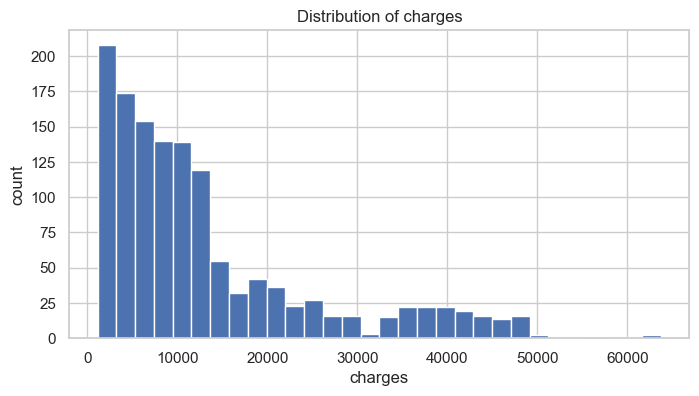

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64
skew: 1.52


In [7]:
plt.figure(figsize=(8,4))
plt.hist(insurance["charges"], bins=30)
plt.xlabel("charges")
plt.ylabel("count")
plt.title("Distribution of charges")
plt.show()

print(insurance["charges"].describe())
print("skew:", round(insurance["charges"].skew(), 2))

**What I learned:** `charges` is strongly right-skewed. Most people sit below \$15,000, but a long tail stretches past \$60,000. The mean (\$13,270) sits well above the median (\$9,382), which confirms the skew. Interestingly, the histogram looks almost *bimodal*, there's a dense cluster of low charges and a secondary bump around \$40,000.

*I wonder...* (1) what separates the low cluster from the high one? (2) Is the high bump a distinct subpopulation (e.g. smokers)? (3) Would a log transform make this look roughly normal?

## 1.2 `age`

Age is a plausible cost driver. I'll use a histogram to see how the sample is distributed across ages.

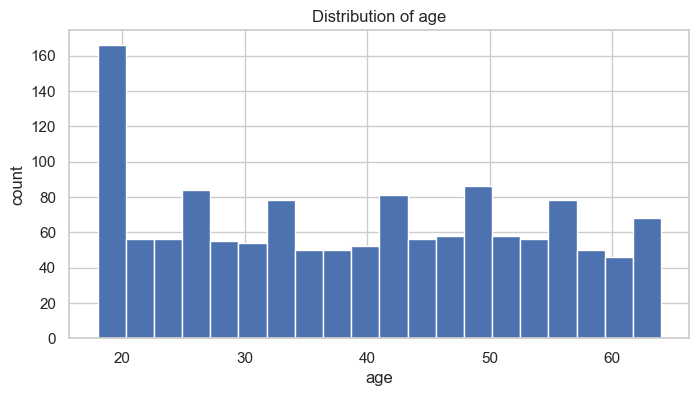

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64


In [8]:
plt.figure(figsize=(8,4))
plt.hist(insurance["age"], bins=20)
plt.xlabel("age")
plt.ylabel("count")
plt.title("Distribution of age")
plt.show()

print(insurance["age"].describe())

**What I learned:** Ages run 18–64 and are fairly uniform, except for a clear spike at the youngest end (18–19). So the sample is roughly evenly spread across adulthood with an over-representation of the youngest adults.

*I wonder...* (1) why are 18–19 year olds over-represented? (2) Do charges rise steadily with age or jump at certain ages? (3) Are the youngest adults driving the low-charges cluster from 1.1?

## 1.3 `bmi`

BMI is a health indicator that could plausibly affect cost. Histogram again.

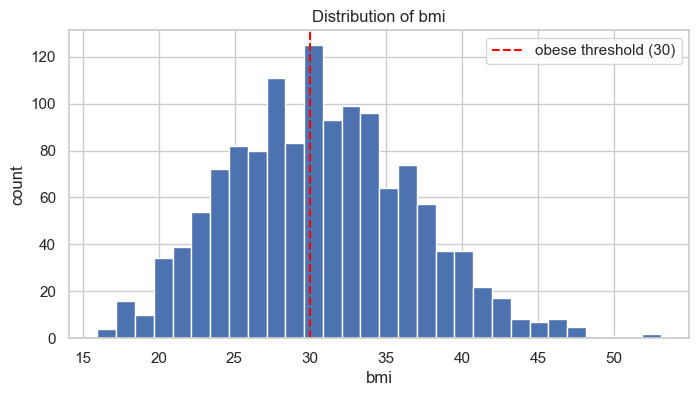

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64
skew: 0.28


In [9]:
plt.figure(figsize=(8,4))
plt.hist(insurance["bmi"], bins=30)
plt.axvline(30, color="red", linestyle="--", label="obese threshold (30)")
plt.xlabel("bmi")
plt.ylabel("count")
plt.title("Distribution of bmi")
plt.legend()
plt.show()

print(insurance["bmi"].describe())
print("skew:", round(insurance["bmi"].skew(), 2))

**What I learned:** BMI is nearly symmetric and bell-shaped, centered around 30.7. Notably the mean BMI sits right at the clinical obesity threshold of 30 — meaning over half the sample is clinically obese.

*I wonder...* (1) does crossing BMI 30 matter for charges, or is the effect gradual? (2) Does BMI interact with smoking? (3) Is BMI related to age?

## 1.4 `children`

A count variable (0–5). A bar chart of frequencies is the natural choice for a discrete count.

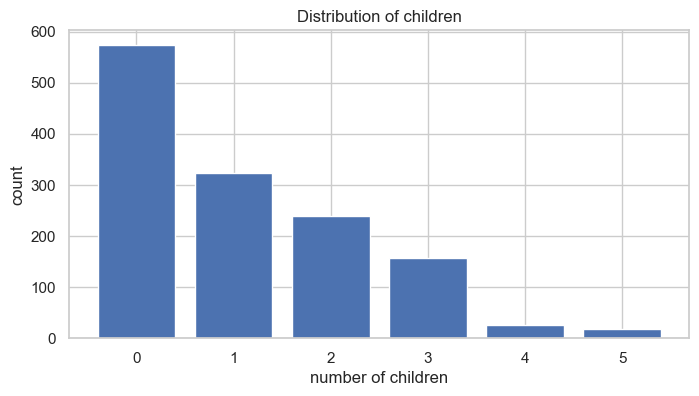

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


In [10]:
counts = insurance["children"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(counts.index, counts.values)
plt.xlabel("number of children")
plt.ylabel("count")
plt.title("Distribution of children")
plt.show()

print(counts)

**What I learned:** Most policyholders have 0 children (574), and frequency drops steadily as children increase; 4–5 children are rare (<25 each). The small cells at 4 and 5 mean any charge estimates there will be noisy.

*I wonder...* (1) do charges go up with more children? (2) Are the tiny groups (4–5) reliable enough to compare? (3) Is having children associated with age?

## 1.5 `smoker`

A two-level category. Bar chart of counts.

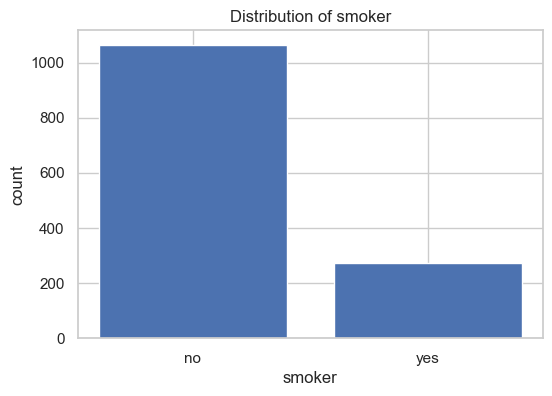

smoker
no     1064
yes     274
Name: count, dtype: int64


In [11]:
counts = insurance["smoker"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.xlabel("smoker")
plt.ylabel("count")
plt.title("Distribution of smoker")
plt.show()

print(counts)

**What I learned:** The sample is imbalanced — only 274 smokers (≈20%) vs 1064 non-smokers. That's realistic but means smoker charge estimates rest on fewer observations.

*I wonder...* (1) is the secondary bump in the `charges` histogram the smokers? (2) How large is the smoker vs non-smoker charge gap? (3) Are smokers evenly distributed across regions?

## 1.6 `sex`

Two-level category. Bar chart.

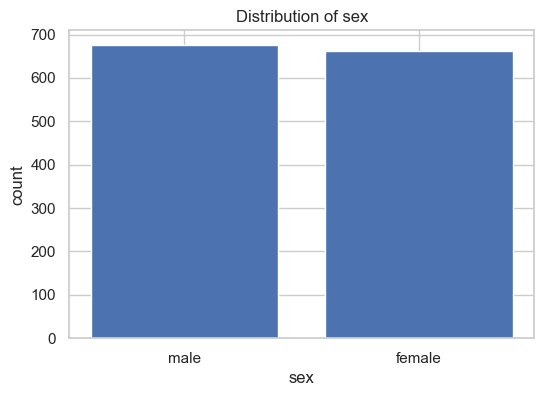

sex
male      676
female    662
Name: count, dtype: int64


In [12]:
counts = insurance["sex"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.xlabel("sex")
plt.ylabel("count")
plt.title("Distribution of sex")
plt.show()

print(counts)

**What I learned:** Essentially balanced — 676 male, 662 female. No sampling concerns here.

*I wonder...* (1) do men and women have different charges? (2) If so, is it explained by smoking rates rather than sex itself? (3) Do smoking rates differ by sex?

## 1.7 `region`

Four-level category. Bar chart.

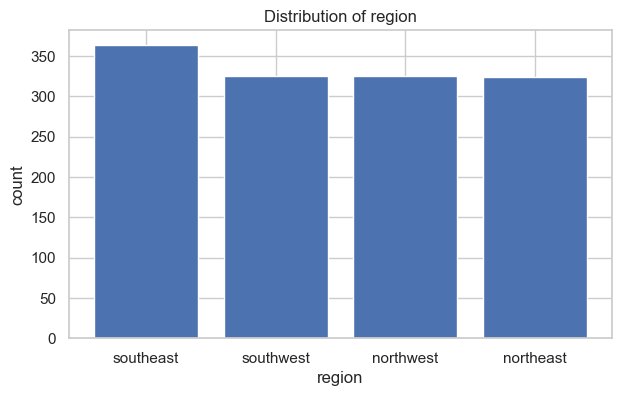

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [13]:
counts = insurance["region"].value_counts()

plt.figure(figsize=(7,4))
plt.bar(counts.index, counts.values)
plt.xlabel("region")
plt.ylabel("count")
plt.title("Distribution of region")
plt.show()

print(counts)

**What I learned:** Roughly even across the four regions (324–364 each), with the southeast slightly largest. Balanced enough for fair comparisons.

*I wonder...* (1) does any region have notably higher charges? (2) Does the southeast differ because of higher BMI or smoking? (3) Are regions balanced on smoker proportion?

# Part 2 — Pairwise Exploration

Each pairing targets `charges`. I'm deliberately not using a correlation matrix to choose pairings, the question already tells me to investigate factors of `charges`, so I pair each candidate factor against it directly.

## 2.1 `smoker` vs `charges`

The `charges` histogram looked bimodal and smoking is the most obvious candidate for a cost split. A boxplot by smoker status will show whether the two groups separate cleanly.

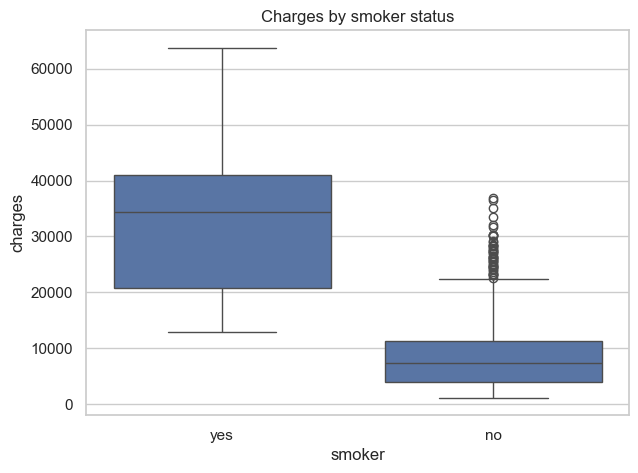

                mean       median  count
smoker                                  
no       8434.268298   7345.40530   1064
yes     32050.231832  34456.34845    274


In [14]:
plt.figure(figsize=(7,5))
sns.boxplot(data=insurance, x="smoker", y="charges")
plt.title("Charges by smoker status")
plt.show()

print(insurance.groupby("smoker")["charges"].agg(["mean", "median", "count"]))

**What I learned:** This is the dominant factor. Non-smokers have a median of ~\$7,300; smokers ~\$34,500 — nearly five times higher. The two boxes barely overlap. The bimodality in the `charges` histogram is explained: it's smokers vs non-smokers.

*I wonder...* (1) is *any* smoker cheaper than the typical non-smoker? (2) Within smokers, what explains their wide spread? (3) Does BMI amplify the smoking cost?

## 2.2 `age` vs `charges`

Two numeric variables: scatter plot. I want to see whether cost rises with age and how tight that relationship is.

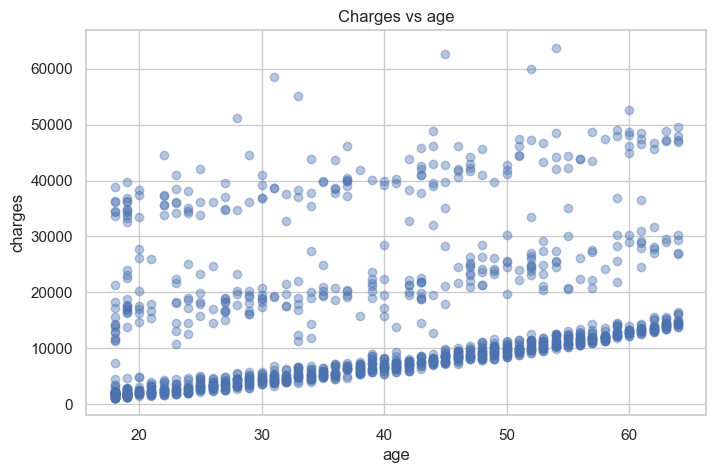

correlation: 0.299


In [15]:
plt.figure(figsize=(8,5))
plt.scatter(insurance["age"], insurance["charges"], alpha=0.4)
plt.xlabel("age")
plt.ylabel("charges")
plt.title("Charges vs age")
plt.show()

print("correlation:", round(insurance["age"].corr(insurance["charges"]), 3))

**What I learned:** Charges rise with age (corr ≈ 0.30), but the scatter shows something more interesting: there appear to be *three roughly parallel bands* climbing with age, not one cloud. The lowest band is densest. This suggests age sets a baseline that's then shifted up by some other factor.

*I wonder...* (1) what are the three bands, is it smoking? (2) Why is the lowest band so much denser? (3) Does the gap between bands widen with age?

## 2.3 `bmi` vs `charges`

Two numeric variables: scatter. Given the bands seen in 2.2, I'll color points by smoker from the start to see if smoking structures this relationship too.

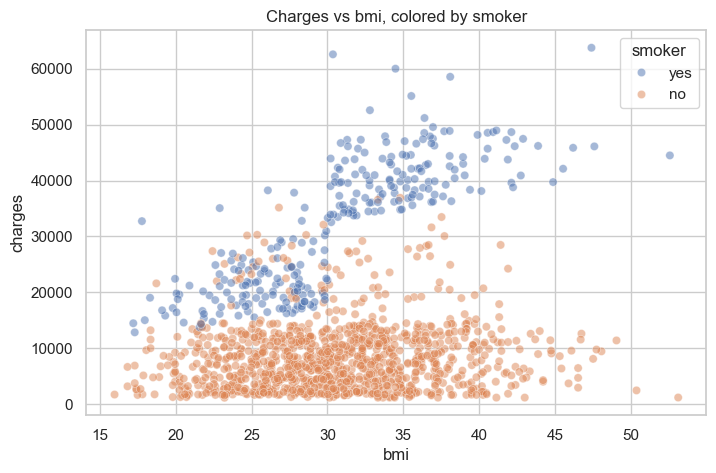

correlation: 0.198


In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=insurance, x="bmi", y="charges", hue="smoker", alpha=0.5)
plt.title("Charges vs bmi, colored by smoker")
plt.show()

print("correlation:", round(insurance["bmi"].corr(insurance["charges"]), 3))

**What I learned:** Overall correlation is weak, but the colored plot reveals why: for non-smokers, BMI barely affects charges (flat band). For smokers, charges climb sharply with BMI, and there's a visible jump around BMI 30. So BMI matters a lot, but only for smokers. This is an interaction, not a simple main effect.

*I wonder...* (1) how big is the smoker BMI>30 penalty exactly? (2) Is the jump really at 30 or gradual? (3) Are there non-smokers in the high-charge region at all?

## 2.4 `children` vs `charges`

`children` is a discrete count, so a boxplot per count value shows the distribution of charges at each level.

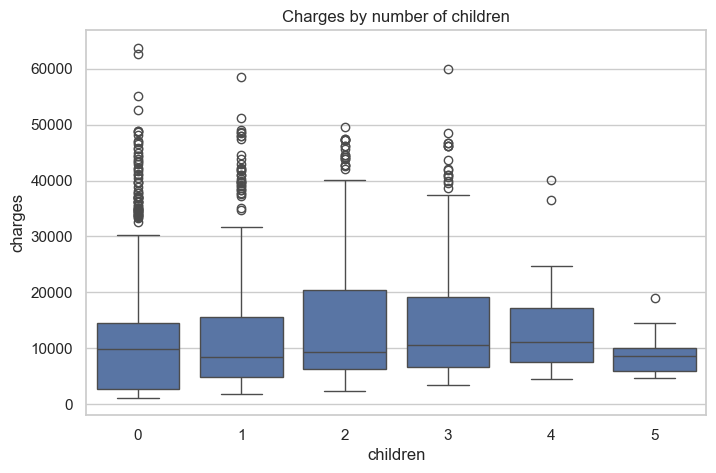

               median  count
children                    
0          9856.95190    574
1          8483.87015    324
2          9264.97915    240
3         10600.54830    157
4         11033.66170     25
5          8589.56505     18


In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=insurance, x="children", y="charges")
plt.title("Charges by number of children")
plt.show()

print(insurance.groupby("children")["charges"].agg(["median", "count"]))

**What I learned:** Median charges are remarkably flat across 0–5 children (~\$8,500–\$11,000). There's no clear trend; if anything the 5-children group is *lowest*, but with only 18 people that's unreliable. Children does not look like a meaningful cost driver.

*I wonder...* (1) is the flat median hiding a difference in the upper tail? (2) Is the small 5-children group just noise? (3) Are families with more children younger or older?

## 2.5 `region` vs `charges`

Categorical (4 levels) vs numeric: boxplot per region.

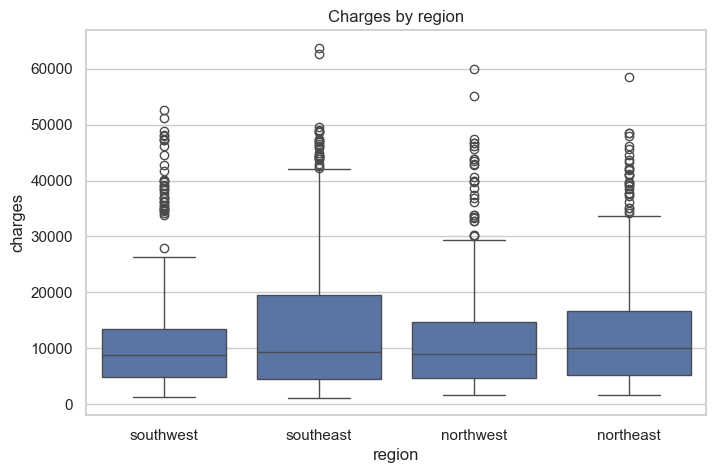

                   mean        median
region                               
northeast  13406.384516  10057.652025
northwest  12417.575374   8965.795750
southeast  14735.411438   9294.131950
southwest  12346.937377   8798.593000


In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=insurance, x="region", y="charges")
plt.title("Charges by region")
plt.show()

print(insurance.groupby("region")["charges"].agg(["mean", "median"]))

**What I learned:** Medians are nearly identical across regions (~\$8,800–\$10,000). The southeast has the highest mean (\$14,735) but a median in line with the others, meaning it has a heavier upper tail rather than being uniformly more expensive. Region on its own is a weak factor.

*I wonder...* (1) why does the southeast have a fatter upper tail, more smokers or higher BMI? (2) Does any region's effect survive after accounting for smoking? (3) Is the southeast's higher BMI the cause?

# Part 3 — Collected Questions

From the explorations above, the questions I noted:

1. What separates the low and high clusters in `charges`?
2. Would a log transform normalize `charges`?
3. Do charges rise steadily with age or jump?
4. Are the youngest adults driving the low-charge cluster?
5. Does crossing BMI 30 matter, or is the effect gradual?
6. Does BMI interact with smoking?
7. Do charges increase with number of children?
8. Are the 4–5 children groups reliable?
9. Is the `charges` bimodality the smokers?
10. How big is the smoker vs non-smoker gap?
11. Do men and women differ in charges, and is it really smoking?
12. Does any region have a heavier upper tail because of smoking/BMI?
13. What are the three parallel bands in the age–charges scatter?
14. Within smokers, what explains the wide spread?
15. Are there any non-smokers in the high-charge region?

I'll answer **five**: #2, #6, #11, #13, and #1/#9 combined (what drives the clusters/bands).

# Part 4 — Answering Five Questions

## Q1 (#13 & #1): What are the three bands in the age–charges scatter?

I saw three parallel bands climbing with age and suspected smoking. I'll redraw the age scatter colored by smoker to test it.

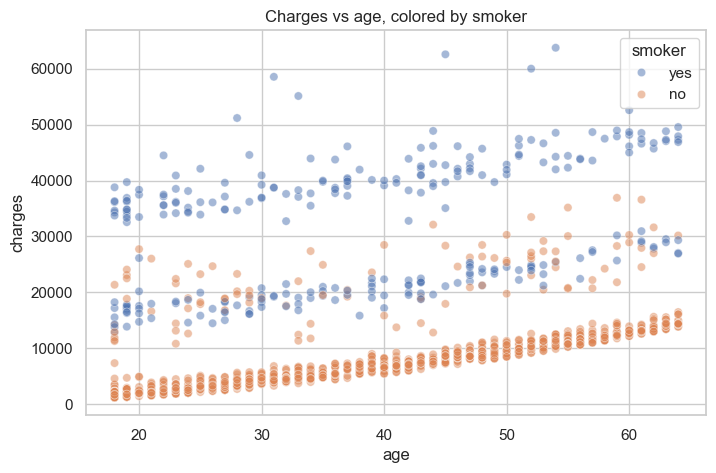

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=insurance, x="age", y="charges", hue="smoker", alpha=0.5)
plt.title("Charges vs age, colored by smoker")
plt.show()

**Answer:** Smoking explains the structure but not perfectly. The bottom band is all non-smokers. The top band is all smokers. The middle band is mixed, smokers with lower BMI and some higher-cost non-smokers. So age provides a rising baseline, and smoking lifts you into a higher band. This directly answers what separates the low/high clusters from 1.1: smoking, scaled by age.

## Q2 (#6 & #5): Does BMI interact with smoking, and does the 30 threshold matter?

In 2.3 BMI seemed to matter only for smokers. I'll quantify it by splitting on the clinical obesity threshold (BMI 30) and comparing mean charges within smoker groups.

                      mean  count
smoker obese                     
no     False   7977.029520    502
       True    8842.691548    562
yes    False  21363.217016    129
       True   41557.989840    145


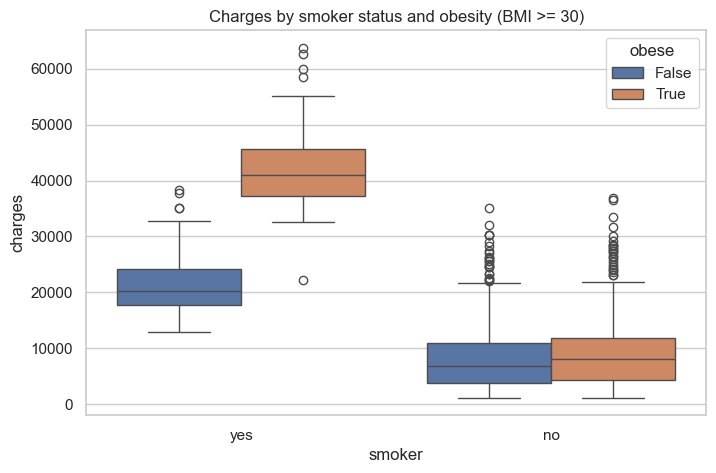

In [20]:
insurance["obese"] = insurance["bmi"] >= 30

print(insurance.groupby(["smoker", "obese"])["charges"].agg(["mean", "count"]))

plt.figure(figsize=(8,5))
sns.boxplot(data=insurance, x="smoker", y="charges", hue="obese")
plt.title("Charges by smoker status and obesity (BMI >= 30)")
plt.show()

**Answer:** Clear interaction. For non-smokers, obesity barely moves charges (\$7,977 → \$8,843). For smokers, obesity nearly *doubles* them (\$21,363 → \$41,558). So BMI is not a standalone driver, it's an amplifier that only activates for smokers. The BMI-30 cutoff captures a real and large jump.

## Q3 (#11): Do men and women differ in charges, and is it really sex or smoking?

In 1.6 sex was balanced; here I check whether charges differ by sex, then whether smoking rates (not sex) explain any gap.

                mean      median
sex                             
female  12569.578844  9412.96250
male    13956.751178  9369.61575

smoker     no    yes
sex                 
female  0.826  0.174
male    0.765  0.235


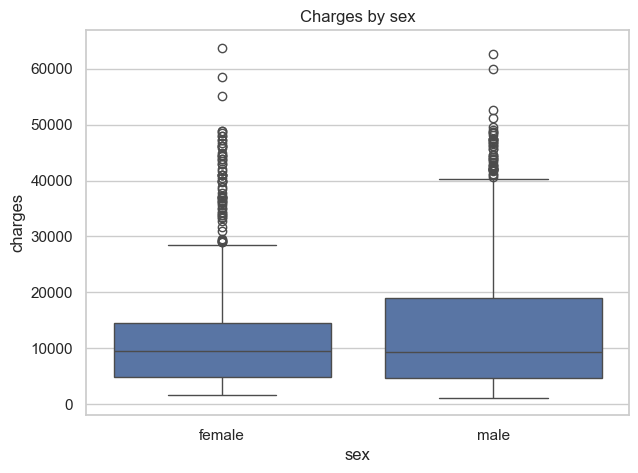

In [21]:
print(insurance.groupby("sex")["charges"].agg(["mean", "median"]))
print()
print(pd.crosstab(insurance["sex"], insurance["smoker"], normalize="index").round(3))

plt.figure(figsize=(7,5))
sns.boxplot(data=insurance, x="sex", y="charges")
plt.title("Charges by sex")
plt.show()

**Answer:** Male mean charges (\$13,957) edge out female (\$12,570), but medians are nearly identical (~\$9,400), so the gap is in the tail, not typical cost. The crosstab shows men smoke at a higher rate, which inflates their mean. The apparent "sex effect" is really a smoking effect, not sex itself.

## Q4 (#2): Would a log transform normalize `charges`?

`charges` was strongly right-skewed. A log transform is the standard fix; I'll histogram `log(charges)` to check.

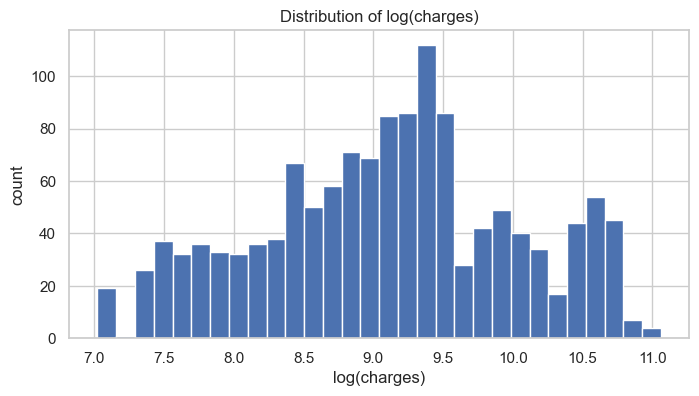

skew before: 1.52
skew after:  -0.09


In [22]:
log_charges = np.log(insurance["charges"])

plt.figure(figsize=(8,4))
plt.hist(log_charges, bins=30)
plt.xlabel("log(charges)")
plt.ylabel("count")
plt.title("Distribution of log(charges)")
plt.show()

print("skew before:", round(insurance["charges"].skew(), 2))
print("skew after: ", round(log_charges.skew(), 2))

**Answer:** The log transform removes most of the right skew and pulls the long tail in. But it doesn't produce a clean bell, the distribution stays lumpy/bimodal, because the two-population structure (smoker vs non-smoker) is real and a transform can't merge them. Useful for modeling, but it confirms the data is genuinely a mixture.

## Q5 (#12): Why does the southeast have a heavier upper tail?

In 2.5 the southeast had the highest mean but an ordinary median. I'll check whether it has more smokers and/or higher BMI.

In [23]:
print(pd.crosstab(insurance["region"], insurance["smoker"], normalize="index").round(3))
print()
print(insurance.groupby("region")["bmi"].mean().round(2))

smoker        no    yes
region                 
northeast  0.793  0.207
northwest  0.822  0.178
southeast  0.750  0.250
southwest  0.822  0.178

region
northeast    29.17
northwest    29.20
southeast    33.36
southwest    30.60
Name: bmi, dtype: float64


**Answer:** The southeast has both the highest smoker proportion and the highest average BMI of the four regions. Given the smoking x BMI interaction from Q2, that combination is exactly what produces extreme charges, so the southeast's heavy upper tail is a consequence of its smoker and BMI mix, not a regional effect in its own right.

# Conclusion

**What are the factors influencing charges?**

- **Smoking is overwhelmingly the largest driver** — a ~5x difference in median charges, and it explains the bimodal shape of `charges`.
- **BMI matters only through smoking**: obesity nearly doubles a smoker's charges but does almost nothing for a non-smoker (a strong interaction).
- **Age** sets a steadily rising baseline that smoking shifts upward (the parallel bands).
- **Children, region, and sex are weak on their own.** Apparent differences (male charges, southeast charges) trace back to differing smoking/BMI mixes rather than the variable itself.

The headline finding is the **smoker x BMI interaction**, the most important structure in the data.